# Model Comparison Notebook

Confronto delle distanze **Unmatched** (autovalori della matrice di Gram normalizzata) e **Wasserstein-2** (prodotto scalare) tra grafi generati da tre modelli sintetici:

- **SBM** (Degree-Corrected Stochastic Block Model): `alpha` ∈ {0, 0.75, 0.5, 1, 1.25, 1.5, 1.75, 2}
- **CM** (Configuration Model / Pareto): `alpha` ∈ {0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1}
- **GM** (Geometric Model): `beta` ∈ {0, 2, 4, 6, 8, 10}

Per ogni modello: generazione → embedding EDRep → distanze pairwise → scatter plot → NMI con ClusterNMF.

In [1]:
import numpy as np
import random
import itertools
import pandas as pd
import os
import ot
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.sparse import csr_matrix
from scipy.stats import pareto
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics.pairwise import euclidean_distances
from EDRep_main.EDRep import NodeEmbedding
from tqdm.notebook import tqdm

In [19]:
def generateSequence(outputfolder, model, args, n_graphs, start_idx=1, verbose=True, append_name='.csv'):
    for i in range(n_graphs):
        df = model(args)
        idx_str = str(start_idx + i).zfill(2)
        df.to_csv(outputfolder + '/EL' + idx_str + append_name, index=False)
        if verbose:
            print("[%--25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end='\r')
    return


def DCSBM(args):
    C, c, l_nodes, theta, symmetric, make_connected = args
    k = len(np.unique(l_nodes))
    n = len(theta)
    c_v = C[l_nodes].T
    fs, ss = [], []
    if symmetric:
        first = np.random.choice(n, int(n*c/2), p=theta/n)
    else:
        first = np.random.choice(n, int(n*c), p=theta/n)
    for i in range(k):
        v = theta * c_v[i]
        first_sel = first[l_nodes[first] == i]
        fs.append(first_sel.tolist())
        second_sel = np.random.choice(n, len(first_sel), p=v/np.sum(v))
        ss.append(second_sel.tolist())
    fs = np.array(list(itertools.chain(*fs)))
    ss = np.array(list(itertools.chain(*ss)))
    if make_connected:
        idx = np.arange(n)[np.logical_not(np.isin(np.arange(n), fs))]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(theta)*np.ones(len(idx))])
    edge_list = np.unique(np.column_stack((fs, ss)), axis=0)
    idx = edge_list[:,0] == edge_list[:,1]
    edge_list[:,1][idx] += 1
    edge_list[:,1][edge_list[:,1] == n] = 0
    if symmetric:
        df = pd.DataFrame(columns=['i', 'j'])
        M = np.maximum(edge_list[:,0], edge_list[:,1])
        m = np.minimum(edge_list[:,0], edge_list[:,1])
        df.i = np.concatenate([M, m])
        df.j = np.concatenate([m, M])
    else:
        df = pd.DataFrame({'i': edge_list[:,0], 'j': edge_list[:,1]})
    return df


def GeometricModel(args):
    X, d, beta = args
    n = np.shape(X)[0]
    no = (X**2)@np.ones(2)
    D = np.zeros((n, n))
    for i in range(n):
        D[i] += no
        D[:,i] += no
    D -= 2*X@X.T
    D = np.sqrt(np.abs(D))
    P = np.exp(-beta*D)
    P = P - np.diag(np.diag(P))
    p = P@np.ones(n)
    P = np.diag(p**(-1)).dot(P)
    idx1 = np.concatenate([np.ones(int(d/2))*i for i in range(n)])
    idx2 = np.concatenate([np.random.choice(np.arange(n), int(d/2), p=P[i], replace=False) for i in range(n)])
    df = pd.DataFrame(columns=['i', 'j'])
    df.i = np.concatenate([idx1, idx2])
    df.j = np.concatenate([idx2, idx1])
    return df

def _sample_pareto(N, alpha, loc=0, scale=1, mean=None):
    """
    Sample N values from a pareto distribution
    """
    b = alpha-1
    r = pareto.rvs(b, loc=loc, scale=scale, size=N)
    if mean:
        r = (r/r.mean()*mean).round()
    return r

def getDegreeFromPareto(n, c, alpha):

    fitness_pareto = np.maximum(_sample_pareto(n, 3.2), 1e-12)
    fitness_pareto = fitness_pareto/np.mean(fitness_pareto)
    fitness_binomial = np.maximum(np.random.binomial(n, c/n, n)/c, 1e-12)
    fitness = np.exp(np.log(fitness_binomial)*(1-alpha) + np.log(fitness_pareto)*alpha)
    theta = fitness/np.mean(fitness)
    degree_sequence = np.maximum(np.random.binomial(n-1, np.minimum(1,theta/n*c)), np.ones(n))
    # degree_sequence = np.random.binomial(n-1, np.minimum(1,theta/n*c))

    return degree_sequence

def gen_with_conf_model(args):
    n, c, alpha = args
    degree_sequence = np.round(getDegreeFromPareto(n, c, alpha)).astype(int)
    if sum(degree_sequence) % 2 != 0:
        degree_sequence[-1] += 1
    G = nx.configuration_model(degree_sequence)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    return pd.DataFrame(G.edges(), columns=['i', 'j'])


def compute_cin_cout(c, k, alpha):
    c_out = c - alpha * np.sqrt(c)
    c_in = k*c - (k-1)*c_out
    return c_in, c_out


def EmbDistance(X, Y, distance_type='unmatched'):
    n1, d1 = X.shape
    n2, d2 = Y.shape
    if d1 != d2:
        raise ValueError('Embedding dimensions differ')
    if distance_type == 'matched':
        if n1 != n2:
            raise ValueError('Matrix sizes differ for matched distance')
        Mxx = X.T@X; Mxy = X.T@Y; Myy = Y.T@Y
        return np.sqrt(np.abs(np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2))
    else:
        lam1 = np.linalg.eigvalsh(X.T@X) / n1
        lam2 = np.linalg.eigvalsh(Y.T@Y) / n2
        return np.linalg.norm(lam1 - lam2)


# def get_adj(filepath):
#     df = pd.read_csv(filepath)
#     G = nx.from_pandas_edgelist(df, 'i', 'j')
#     return nx.adjacency_matrix(G).astype(float)

def get_adj(filepath, n_nodes=None):
    df = pd.read_csv(filepath)
    G = nx.from_pandas_edgelist(df, 'i', 'j')
    if n_nodes is not None:
        # aggiunge i nodi mancanti come isolati
        G.add_nodes_from(range(n_nodes))
    return nx.adjacency_matrix(G, nodelist=range(n_nodes or G.number_of_nodes())).astype(float)


def node_embedding(g, dim_embedding, seed=42):
    rdn_state = np.random.get_state()
    random.seed(seed); np.random.seed(seed)
    X_total = NodeEmbedding(g, dim=dim_embedding, k=1, verbose=False).X
    np.random.set_state(rdn_state)
    return X_total


def w2_distance(emb_1, emb_2):
    S_1 = emb_1@emb_1.T; S_2 = emb_2@emb_2.T
    return ot.wasserstein_1d(S_1.flatten(), S_2.flatten(), p=2)**(1/2)


def create_embeddings(path_files, dim):
    embeddings = []
    for file in tqdm(path_files, desc="Calcolando embeddings"):
        embeddings.append(node_embedding(get_adj(file), dim))
    return embeddings


def NMF_kmeans(M, k):
    n, _ = M.shape
    Mt = M + np.eye(n)*np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)
    Y = NMF(n_components=k, max_iter=2000).fit(Mt).components_
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))


def ClusterNMF(M, k):
    est_l, score = NMF_kmeans(M, k)
    for _ in range(20):
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_; est_l = est_l_
    return est_l



def precompute_features(embeddings):
    """Pre-calcola le features costose una sola volta per embedding.

    Problema del loop naive: ogni embedding X appare in (N-1) coppie, quindi
    eigvalsh(X.T@X) e S=X@X.T vengono ricalcolati (N-1) volte → spreco (N-1)×.
    Con N=64: 63 calcoli ridondanti per embedding, 4032 totali invece di 64.

    Returns
    -------
    eigenvalues   : lista di array (d,)  — autovalori normalizzati per unmatched
    S_sorted_list : lista di array (n²,) — distribuzione S=X@X.T pre-ordinata per W2
    """
    eigenvalues, S_sorted_list = [], []
    for X in tqdm(embeddings, desc="Pre-computing features", leave=False):
        n = len(X)
        eigenvalues.append(np.linalg.eigvalsh(X.T @ X) / n)
        S_sorted_list.append(np.sort((X @ X.T).ravel()))
    return eigenvalues, S_sorted_list


def compute_distance_matrices(all_emb, labels, model_name):
    """Calcola unmatched e wasserstein in modo ottimizzato.

    Ottimizzazioni rispetto al loop coppia-per-coppia:
    1. Pre-computa eigenvalues e S_sorted una sola volta per embedding  → (N-1)× speedup
    2. Unmatched vettorizzato con euclidean_distances (una sola BLAS call) → no loop
    3. W2 con formula numpy diretta su array pre-ordinati, senza overhead POT:
           W2 = sqrt(mean((s_i - s_j)²))   [equivalente a ot.wasserstein_1d(...,p=2)**0.5]

    Returns
    -------
    df            : DataFrame con colonne Unmatched, Wasserstein, Type
    D_unmatched   : matrice N×N delle distanze unmatched
    D_wasserstein : matrice N×N delle distanze Wasserstein
    """
    N = len(all_emb)
    pairs = list(itertools.combinations(range(N), 2))

    # 1. Pre-computazione: O(N) invece di O(N²)
    eigenvalues, S_sorted_list = precompute_features(all_emb)

    # 2. Unmatched: L2 tra vettori di autovalori → una sola chiamata vettorizzata
    eig_matrix = np.stack(eigenvalues)           # (N, d)
    D_unmatched = euclidean_distances(eig_matrix) # (N, N) — zero loop

    # 3. Wasserstein: loop con array pre-ordinati e formula numpy diretta
    w2_vals = []
    for i, j in tqdm(pairs, desc=f"{model_name} W2", leave=True):
        s1, s2 = S_sorted_list[i], S_sorted_list[j]
        if len(s1) == len(s2):
            # Formula chiusa: W2 = sqrt(mean((sort(a)-sort(b))²))
            # Matematicamente identica a ot.wasserstein_1d(a,b,p=2)**0.5
            # ma evita overhead POT e re-sorting (già fatto in pre-computazione)
            w2_vals.append(np.sqrt(np.mean((s1 - s2) ** 2)))
        else:
            # Fallback per grafi di taglia diversa (raro con CM/n=1000)
            w2_vals.append(ot.wasserstein_1d(s1, s2, p=2) ** 0.5)

    D_wasserstein = squareform(w2_vals)

    # Costruisci categorie e dataframe
    categories = []
    for i, j in pairs:
        a_i, a_j = labels[i], labels[j]
        if a_i == a_j:
            categories.append(f"{model_name} {a_i:.2f}")
        else:
            a_min, a_max = sorted([a_i, a_j])
            categories.append(f"{a_min:.2f} vs {a_max:.2f}")

    df = pd.DataFrame({
        'Unmatched':   [D_unmatched[i, j] for i, j in pairs],
        'Wasserstein': w2_vals,
        'Type':        categories,
    })
    return df, D_unmatched, D_wasserstein


In [22]:
# Parametri condivisi tra tutti i modelli
n_nodes = 1000
gamma = 0.8
symmetric = True
make_connected = True
c = 10
dim = 32
n_graphs = 3 # grafi per valore di parametro

sbm_alphas = [0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
cm_alphas  = [0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1]
gm_betas   = [0, 1, 2, 3, 4, 5, 6]

In [23]:
base_sbm = os.path.join("data", "synthetic_graphs", "generated_sbm")
base_cm  = os.path.join("data", "synthetic_graphs", "generated_cm")
base_gm  = os.path.join("data", "synthetic_graphs", "generated_gm")

for a in sbm_alphas:
    os.makedirs(os.path.join(base_sbm, f"alpha_{a:.2f}"), exist_ok=True)
for a in cm_alphas:
    os.makedirs(os.path.join(base_cm, f"alpha_{a:.2f}"), exist_ok=True)
for b in gm_betas:
    os.makedirs(os.path.join(base_gm, f"beta_{b}"), exist_ok=True)

print("Cartelle create.")

Cartelle create.


---
## 1. Stochastic Block Model (SBM)

**Parametro**: `alpha` ∈ {0, 0.5, 1, 1.5, 1.75, 2} — k=4 comunità, n=1000 nodi

- `alpha=0`: ER (nessuna struttura di comunità)
- `alpha` crescente → comunità più nette (c_in cresce, c_out scende)

In [10]:
k_sbm = 4
theta_sbm = np.ones(n_nodes)
l_sbm = np.zeros(n_nodes)
for i in range(k_sbm):
    l_sbm[i*(n_nodes//k_sbm):(i+1)*(n_nodes//k_sbm)] = i
l_sbm = l_sbm.astype(int)

for a in sbm_alphas:
    c_in, c_out = compute_cin_cout(c, k_sbm, a)
    C_sbm = np.ones((k_sbm, k_sbm)) * c_out + np.diag(np.ones(k_sbm)) * (c_in - c_out)
    folder = os.path.join(base_sbm, f"alpha_{a:.2f}")
    print(f"Generazione SBM alpha={a:.2f} -> {folder}")
    generateSequence(folder, DCSBM, (C_sbm, c, l_sbm, theta_sbm, symmetric, make_connected),
                     n_graphs, start_idx=1, verbose=True)
    print()

Generazione SBM alpha=0.00 -> data\synthetic_graphs\generated_sbm\alpha_0.00
[================>        ] 100%
Generazione SBM alpha=0.50 -> data\synthetic_graphs\generated_sbm\alpha_0.50
[================>        ] 100%
Generazione SBM alpha=0.75 -> data\synthetic_graphs\generated_sbm\alpha_0.75
[================>        ] 100%
Generazione SBM alpha=1.00 -> data\synthetic_graphs\generated_sbm\alpha_1.00
[================>        ] 100%
Generazione SBM alpha=1.25 -> data\synthetic_graphs\generated_sbm\alpha_1.25
[================>        ] 100%
Generazione SBM alpha=1.50 -> data\synthetic_graphs\generated_sbm\alpha_1.50
[================>        ] 100%
Generazione SBM alpha=1.75 -> data\synthetic_graphs\generated_sbm\alpha_1.75
[================>        ] 100%
Generazione SBM alpha=2.00 -> data\synthetic_graphs\generated_sbm\alpha_2.00
[================>        ] 100%


In [11]:
embeddings_sbm = {}
for a in sbm_alphas:
    folder = os.path.join(base_sbm, f"alpha_{a:.2f}")
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    print(f"Embedding SBM alpha={a:.2f} ({len(files)} grafi)...")
    embeddings_sbm[a] = create_embeddings(files, dim)

Embedding SBM alpha=0.00 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding SBM alpha=0.50 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding SBM alpha=0.75 (3 grafi)...


...

Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding SBM alpha=1.75 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding SBM alpha=2.00 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

In [12]:
all_emb_sbm, labels_sbm = [], []
for a, emb_list in embeddings_sbm.items():
    for emb in emb_list:
        all_emb_sbm.append(emb); labels_sbm.append(a)

df_sbm, D_unmatched_sbm, D_wasserstein_sbm = compute_distance_matrices(
    all_emb_sbm, labels_sbm, "SBM")

Pre-computing features:   0%|          | 0/24 [00:00<?, ?it/s]

SBM W2:   0%|          | 0/276 [00:00<?, ?it/s]

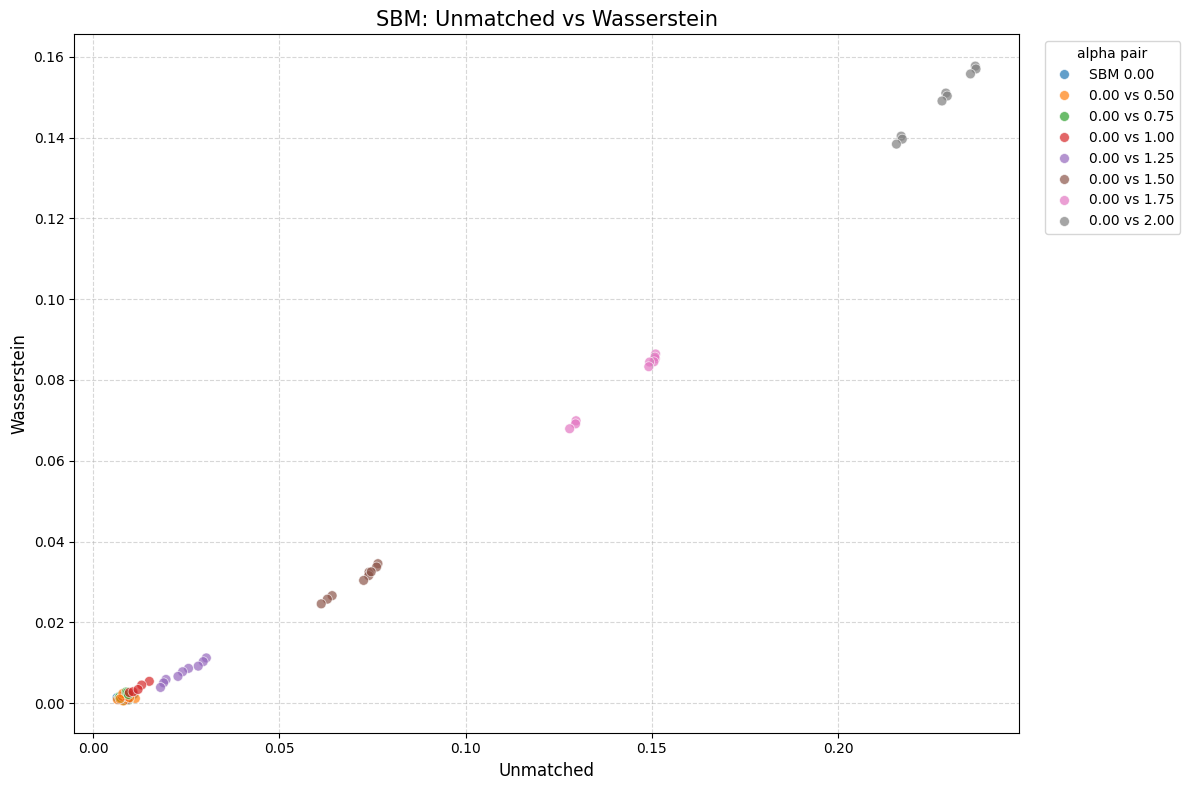

In [13]:
sbm_keep = ["SBM 0.00", "0.00 vs 0.50", "0.00 vs 0.75", "0.00 vs 1.00",
            "0.00 vs 1.25", "0.00 vs 1.50", "0.00 vs 1.75", "0.00 vs 2.00"]
df_sbm_f = df_sbm[df_sbm['Type'].isin(sbm_keep)]

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_sbm_f, x='Unmatched', y='Wasserstein',
                hue='Type', hue_order=sbm_keep, palette='tab10', alpha=0.7, s=50, ax=ax)
ax.set_title("SBM: Unmatched vs Wasserstein", fontsize=15)
ax.set_xlabel("Unmatched", fontsize=12); ax.set_ylabel("Wasserstein", fontsize=12)
ax.legend(title="alpha pair", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [14]:
l_true_sbm = np.concatenate([[i]*n_graphs for i in range(len(sbm_alphas))])
k_all_sbm = len(sbm_alphas)
nmi_all_u_sbm = NMI(ClusterNMF(D_unmatched_sbm, k_all_sbm), l_true_sbm)
nmi_all_w_sbm = NMI(ClusterNMF(D_wasserstein_sbm, k_all_sbm), l_true_sbm)
print(f"SBM NMI globale — Unmatched:   {nmi_all_u_sbm:.4f}")
print(f"SBM NMI globale — Wasserstein: {nmi_all_w_sbm:.4f}")

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


SBM NMI globale — Unmatched:   0.7166
SBM NMI globale — Wasserstein: 0.6416


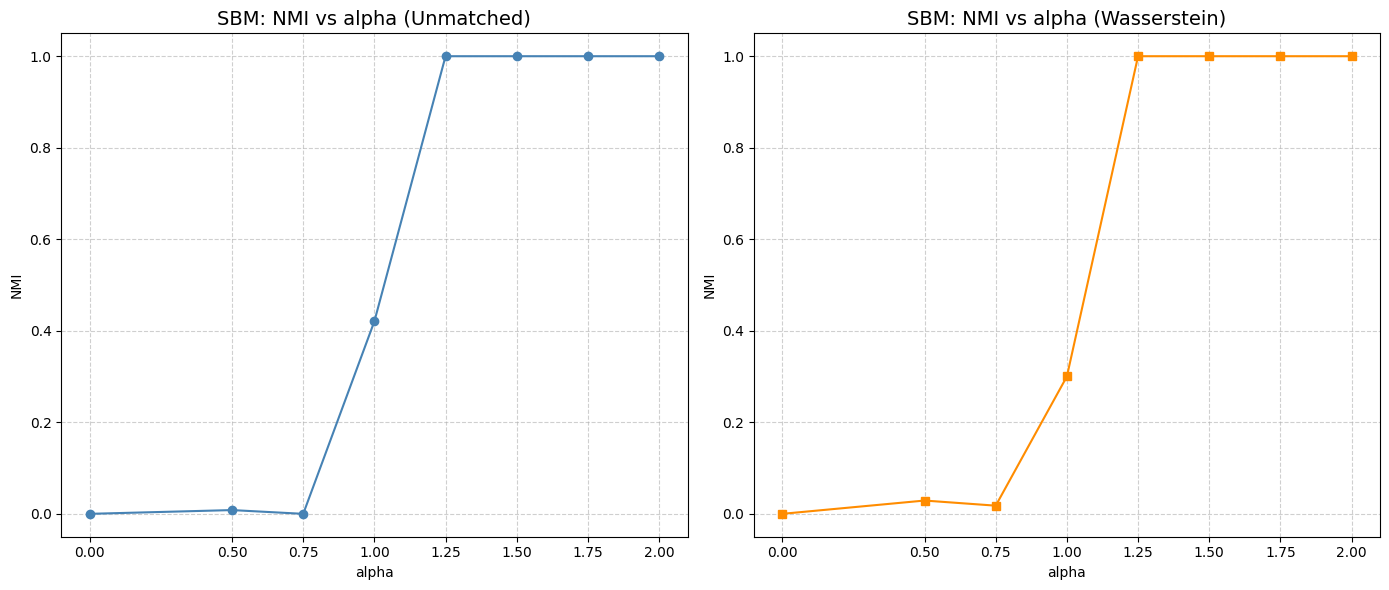

In [ ]:
nmi_u_sbm_curve, nmi_w_sbm_curve = [], []

for i, a in enumerate(sbm_alphas):
    if i == 0:
        nmi_u_sbm_curve.append(0.0); nmi_w_sbm_curve.append(0.0); continue
    idx = np.concatenate([np.arange(0, n_graphs), np.arange(i*n_graphs, (i+1)*n_graphs)])
    l_sub = np.concatenate([np.zeros(n_graphs), np.ones(n_graphs)])
    nmi_u_sbm_curve.append(NMI(ClusterNMF(D_unmatched_sbm[np.ix_(idx,idx)], k=2), l_sub))
    nmi_w_sbm_curve.append(NMI(ClusterNMF(D_wasserstein_sbm[np.ix_(idx,idx)], k=2), l_sub))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(sbm_alphas, nmi_u_sbm_curve, marker='o', color='steelblue')
ax1.set_title("SBM: NMI vs alpha (Unmatched)", fontsize=14)
ax1.set_xlabel("alpha"); ax1.set_ylabel("NMI")
ax1.set_xticks(sbm_alphas); ax1.set_ylim(-0.05, 1.05); ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(sbm_alphas, nmi_w_sbm_curve, marker='s', color='darkorange')
ax2.set_title("SBM: NMI vs alpha (Wasserstein)", fontsize=14)
ax2.set_xlabel("alpha"); ax2.set_ylabel("NMI")
ax2.set_xticks(sbm_alphas); ax2.set_ylim(-0.05, 1.05); ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

---
## 2. Configuration Model (CM)

**Parametro**: `alpha` ∈ {0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1}

- `alpha=0`: distribuzione dei gradi binomiale (simile a ER)
- `alpha` crescente → coda pesante Pareto (maggiore eterogeneità dei gradi)

In [24]:
for a in cm_alphas:
    folder = os.path.join(base_cm, f"alpha_{a:.2f}")
    n_cm = n_nodes  # taglia fissa per tutti gli alpha
    print(f"Generazione CM alpha={a:.2f} -> {folder}")
    generateSequence(folder, gen_with_conf_model, (n_cm, c, a),
                     n_graphs, start_idx=1, verbose=True)
    print()

Generazione CM alpha=0.00 -> data\synthetic_graphs\generated_cm\alpha_0.00
[================>        ] 100%
Generazione CM alpha=0.20 -> data\synthetic_graphs\generated_cm\alpha_0.20
[================>        ] 100%
Generazione CM alpha=0.40 -> data\synthetic_graphs\generated_cm\alpha_0.40
[================>        ] 100%
Generazione CM alpha=0.60 -> data\synthetic_graphs\generated_cm\alpha_0.60
[================>        ] 100%
Generazione CM alpha=0.70 -> data\synthetic_graphs\generated_cm\alpha_0.70
[================>        ] 100%
Generazione CM alpha=0.80 -> data\synthetic_graphs\generated_cm\alpha_0.80
[================>        ] 100%
Generazione CM alpha=0.90 -> data\synthetic_graphs\generated_cm\alpha_0.90
[================>        ] 100%
Generazione CM alpha=1.00 -> data\synthetic_graphs\generated_cm\alpha_1.00
[================>        ] 100%


In [25]:
embeddings_cm = {}
for a in cm_alphas:
    folder = os.path.join(base_cm, f"alpha_{a:.2f}")
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    print(f"Embedding CM alpha={a:.2f} ({len(files)} grafi)...")
    embeddings_cm[a] = create_embeddings(files, dim)

Embedding CM alpha=0.00 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding CM alpha=0.20 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding CM alpha=0.40 (3 grafi)...


...

Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding CM alpha=0.90 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding CM alpha=1.00 (3 grafi)...


Calcolando embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

In [26]:
all_emb_cm, labels_cm = [], []
for a, emb_list in embeddings_cm.items():
    for emb in emb_list:
        all_emb_cm.append(emb); labels_cm.append(a)

df_cm, D_unmatched_cm, D_wasserstein_cm = compute_distance_matrices(
    all_emb_cm, labels_cm, "CM")

Pre-computing features:   0%|          | 0/24 [00:00<?, ?it/s]

CM W2:   0%|          | 0/276 [00:00<?, ?it/s]

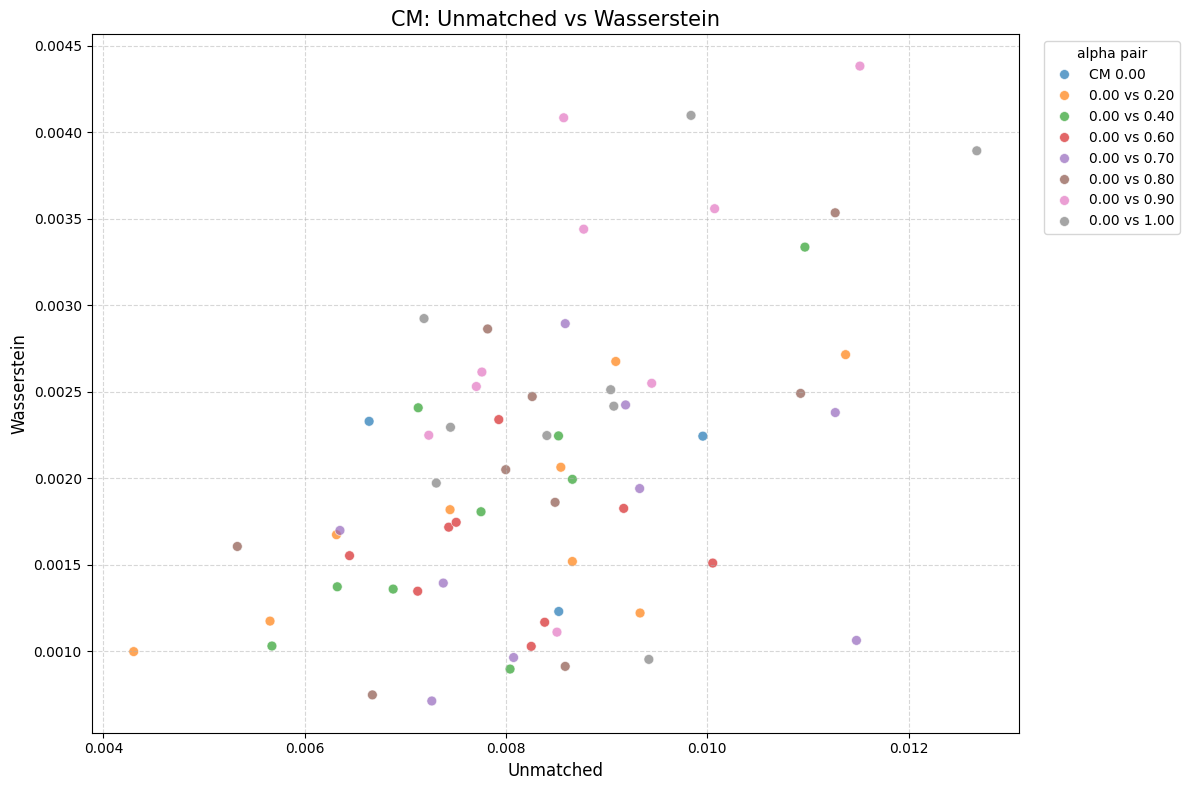

In [27]:
cm_keep = ["CM 0.00", "0.00 vs 0.20", "0.00 vs 0.40", "0.00 vs 0.60",
           "0.00 vs 0.70", "0.00 vs 0.80", "0.00 vs 0.90", "0.00 vs 1.00"]
df_cm_f = df_cm[df_cm['Type'].isin(cm_keep)]

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_cm_f, x='Unmatched', y='Wasserstein',
                hue='Type', hue_order=cm_keep, palette='tab10', alpha=0.7, s=50, ax=ax)
ax.set_title("CM: Unmatched vs Wasserstein", fontsize=15)
ax.set_xlabel("Unmatched", fontsize=12); ax.set_ylabel("Wasserstein", fontsize=12)
ax.legend(title="alpha pair", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [ ]:
l_true_cm = np.concatenate([[i]*n_graphs for i in range(len(cm_alphas))])
k_all_cm = len(cm_alphas)
nmi_all_u_cm = NMI(ClusterNMF(D_unmatched_cm, k_all_cm), l_true_cm)
nmi_all_w_cm = NMI(ClusterNMF(D_wasserstein_cm, k_all_cm), l_true_cm)
print(f"CM NMI globale — Unmatched:   {nmi_all_u_cm:.4f}")
print(f"CM NMI globale — Wasserstein: {nmi_all_w_cm:.4f}")

CM NMI globale — Unmatched:   0.1818
CM NMI globale — Wasserstein: 0.1747


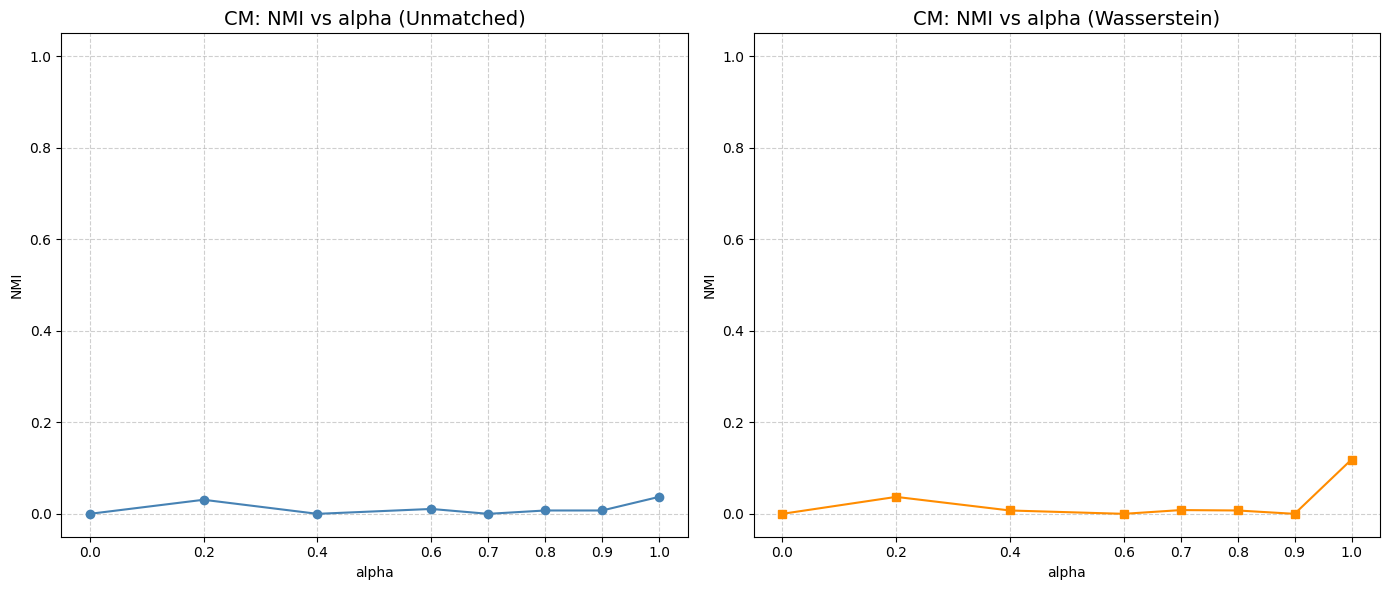

In [ ]:
nmi_u_cm_curve, nmi_w_cm_curve = [], []

for i, a in enumerate(cm_alphas):
    if i == 0:
        nmi_u_cm_curve.append(0.0); nmi_w_cm_curve.append(0.0); continue
    idx = np.concatenate([np.arange(0, n_graphs), np.arange(i*n_graphs, (i+1)*n_graphs)])
    l_sub = np.concatenate([np.zeros(n_graphs), np.ones(n_graphs)])
    nmi_u_cm_curve.append(NMI(ClusterNMF(D_unmatched_cm[np.ix_(idx,idx)], k=2), l_sub))
    nmi_w_cm_curve.append(NMI(ClusterNMF(D_wasserstein_cm[np.ix_(idx,idx)], k=2), l_sub))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(cm_alphas, nmi_u_cm_curve, marker='o', color='steelblue')
ax1.set_title("CM: NMI vs alpha (Unmatched)", fontsize=14)
ax1.set_xlabel("alpha"); ax1.set_ylabel("NMI")
ax1.set_xticks(cm_alphas); ax1.set_ylim(-0.05, 1.05); ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(cm_alphas, nmi_w_cm_curve, marker='s', color='darkorange')
ax2.set_title("CM: NMI vs alpha (Wasserstein)", fontsize=14)
ax2.set_xlabel("alpha"); ax2.set_ylabel("NMI")
ax2.set_xticks(cm_alphas); ax2.set_ylim(-0.05, 1.05); ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

---
## 3. Geometric Model (GM)

**Parametro**: `beta` ∈ {0, 2, 4, 6, 8, 10}

- `beta=0`: connessioni geometriche uniformi (simile a ER)
- `beta` crescente → maggiore località spaziale (cluster geografici)

In [ ]:
for b in gm_betas:
    folder = os.path.join(base_gm, f"beta_{b}")
    n_gm = n_nodes  # taglia fissa per tutti i beta
    r_gm = np.random.uniform(0, 1, n_gm)
    theta_gm = np.random.uniform(0, 2*np.pi, n_gm)
    X_gm = np.column_stack([r_gm*np.cos(theta_gm), r_gm*np.sin(theta_gm)])
    print(f"Generazione GM beta={b} -> {folder}")
    generateSequence(folder, GeometricModel, (X_gm, c, b),
                     n_graphs, start_idx=1, verbose=True)
    print()

Generazione GM beta=0 -> data\synthetic_graphs\generated_gm\beta_0
[======================>  ] 100%
Generazione GM beta=1 -> data\synthetic_graphs\generated_gm\beta_1
[======================>  ] 100%
Generazione GM beta=2 -> data\synthetic_graphs\generated_gm\beta_2
[======================>  ] 100%
Generazione GM beta=3 -> data\synthetic_graphs\generated_gm\beta_3
[======================>  ] 100%
Generazione GM beta=4 -> data\synthetic_graphs\generated_gm\beta_4
[======================>  ] 100%
Generazione GM beta=5 -> data\synthetic_graphs\generated_gm\beta_5
[======================>  ] 100%
Generazione GM beta=6 -> data\synthetic_graphs\generated_gm\beta_6
[======================>  ] 100%


In [ ]:
embeddings_gm = {}
for b in gm_betas:
    folder = os.path.join(base_gm, f"beta_{b}")
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    print(f"Embedding GM beta={b} ({len(files)} grafi)...")
    embeddings_gm[b] = create_embeddings(files, dim)

Embedding GM beta=0 (10 grafi)...


Calcolando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding GM beta=1 (10 grafi)...


Calcolando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding GM beta=2 (10 grafi)...


...

Calcolando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding GM beta=5 (10 grafi)...


Calcolando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding GM beta=6 (10 grafi)...


Calcolando embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
all_emb_gm, labels_gm = [], []
for b, emb_list in embeddings_gm.items():
    for emb in emb_list:
        all_emb_gm.append(emb); labels_gm.append(b)

df_gm, D_unmatched_gm, D_wasserstein_gm = compute_distance_matrices(
    all_emb_gm, labels_gm, "GM")

Pre-computing features:   0%|          | 0/70 [00:00<?, ?it/s]

GM W2:   0%|          | 0/2415 [00:00<?, ?it/s]

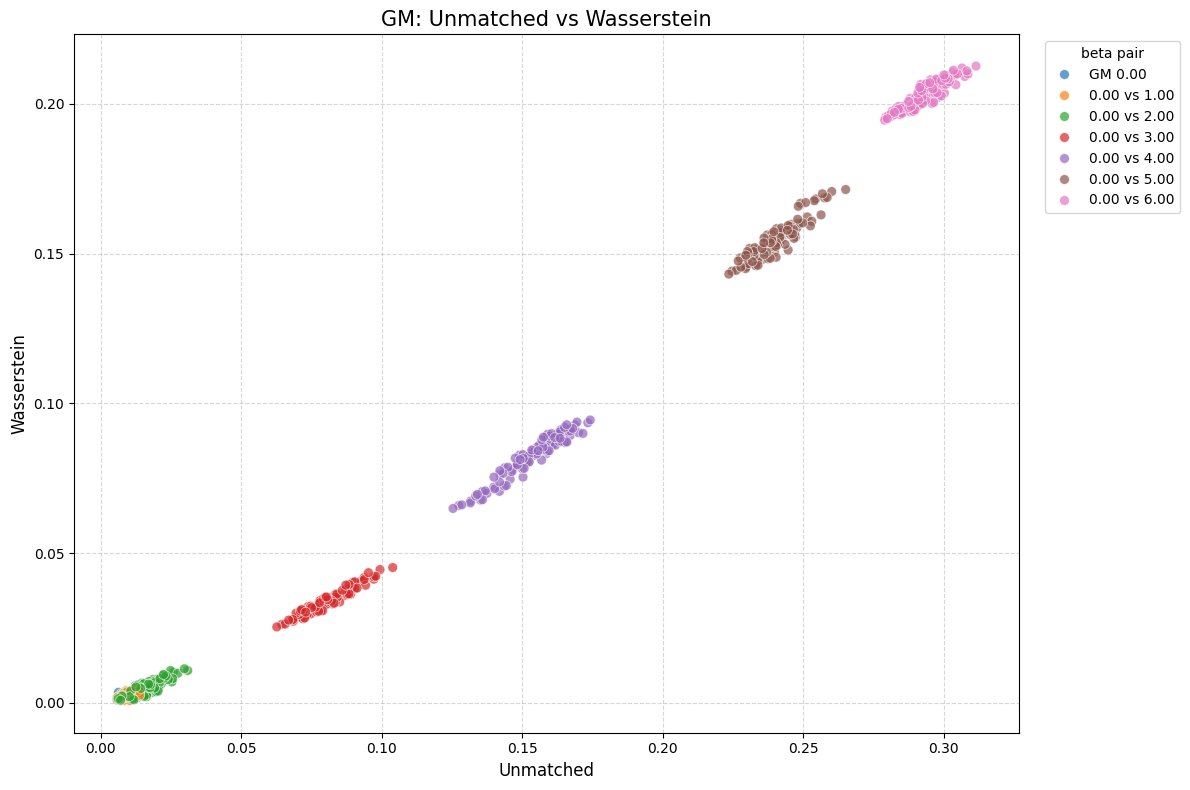

In [ ]:
gm_keep = ["GM 0.00", "0.00 vs 1.00", "0.00 vs 2.00", "0.00 vs 3.00", "0.00 vs 4.00", "0.00 vs 5.00", "0.00 vs 6.00"]
df_gm_f = df_gm[df_gm['Type'].isin(gm_keep)]

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_gm_f, x='Unmatched', y='Wasserstein',
                hue='Type', hue_order=gm_keep, palette='tab10', alpha=0.7, s=50, ax=ax)
ax.set_title("GM: Unmatched vs Wasserstein", fontsize=15)
ax.set_xlabel("Unmatched", fontsize=12); ax.set_ylabel("Wasserstein", fontsize=12)
ax.legend(title="beta pair", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [ ]:
l_true_gm = np.concatenate([[i]*n_graphs for i in range(len(gm_betas))])
k_all_gm = len(gm_betas)
nmi_all_u_gm = NMI(ClusterNMF(D_unmatched_gm, k_all_gm), l_true_gm)
nmi_all_w_gm = NMI(ClusterNMF(D_wasserstein_gm, k_all_gm), l_true_gm)
print(f"GM NMI globale — Unmatched:   {nmi_all_u_gm:.4f}")
print(f"GM NMI globale — Wasserstein: {nmi_all_w_gm:.4f}")

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


GM NMI globale — Unmatched:   0.7862
GM NMI globale — Wasserstein: 0.7765


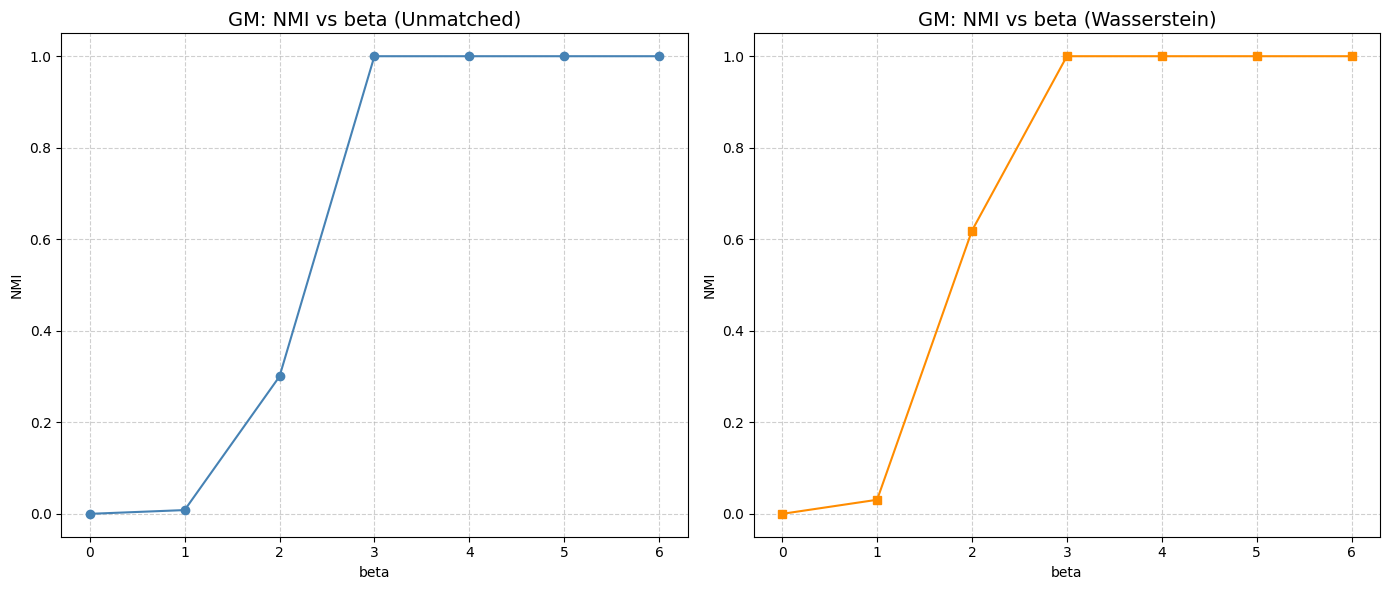

In [ ]:
nmi_u_gm_curve, nmi_w_gm_curve = [], []

for i, b in enumerate(gm_betas):
    if i == 0:
        nmi_u_gm_curve.append(0.0); nmi_w_gm_curve.append(0.0); continue
    idx = np.concatenate([np.arange(0, n_graphs), np.arange(i*n_graphs, (i+1)*n_graphs)])
    l_sub = np.concatenate([np.zeros(n_graphs), np.ones(n_graphs)])
    nmi_u_gm_curve.append(NMI(ClusterNMF(D_unmatched_gm[np.ix_(idx,idx)], k=2), l_sub))
    nmi_w_gm_curve.append(NMI(ClusterNMF(D_wasserstein_gm[np.ix_(idx,idx)], k=2), l_sub))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(gm_betas, nmi_u_gm_curve, marker='o', color='steelblue')
ax1.set_title("GM: NMI vs beta (Unmatched)", fontsize=14)
ax1.set_xlabel("beta"); ax1.set_ylabel("NMI")
ax1.set_xticks(gm_betas); ax1.set_ylim(-0.05, 1.05); ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(gm_betas, nmi_w_gm_curve, marker='s', color='darkorange')
ax2.set_title("GM: NMI vs beta (Wasserstein)", fontsize=14)
ax2.set_xlabel("beta"); ax2.set_ylabel("NMI")
ax2.set_xticks(gm_betas); ax2.set_ylim(-0.05, 1.05); ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


## Confronto NMI tra tutti i modelli

Griglia 3×2 con le curve NMI vs parametro per tutti e tre i modelli.
Colonna sinistra: distanza Unmatched. Colonna destra: distanza Wasserstein.

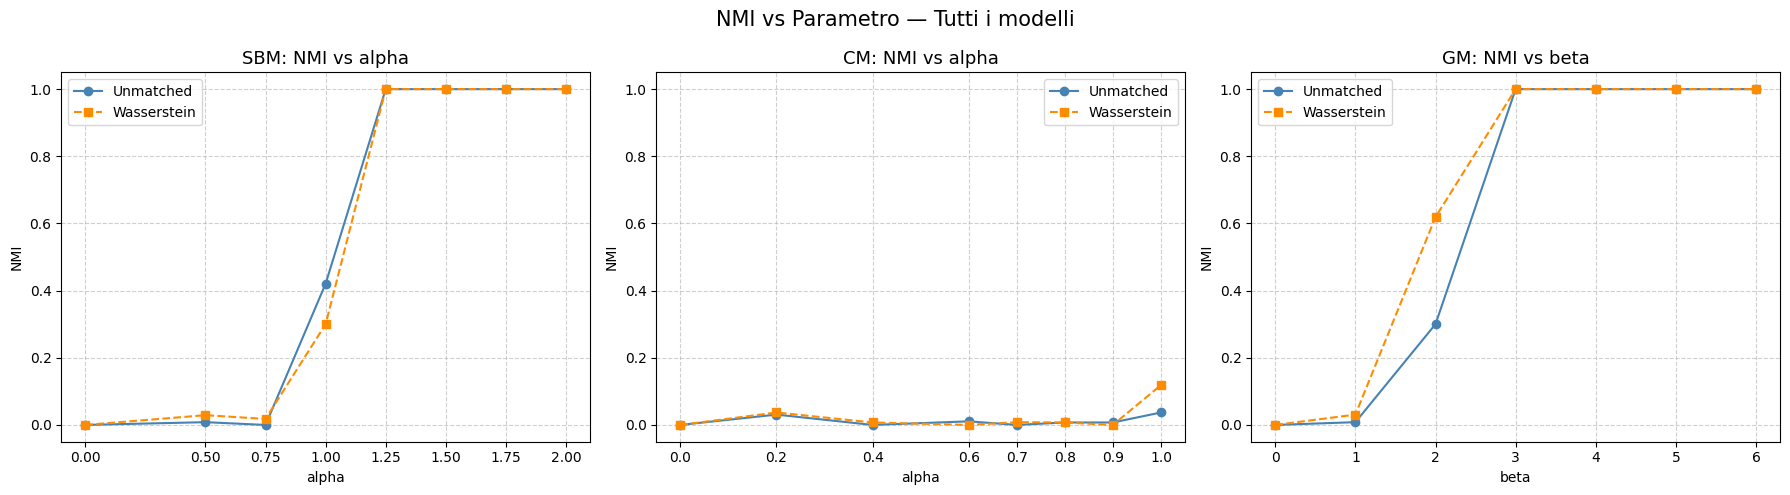

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NMI vs Parametro — Tutti i modelli", fontsize=15)

model_configs = [
    ("SBM", sbm_alphas, nmi_u_sbm_curve, nmi_w_sbm_curve, "alpha"),
    ("CM",  cm_alphas,  nmi_u_cm_curve,  nmi_w_cm_curve,  "alpha"),
    ("GM",  gm_betas,   nmi_u_gm_curve,  nmi_w_gm_curve,  "beta"),
]

for ax, (name, params, nmi_u, nmi_w, xlabel) in zip(axes, model_configs):
    ax.plot(params, nmi_u, marker="o", color="steelblue",  linestyle="-",  label="Unmatched")
    ax.plot(params, nmi_w, marker="s", color="darkorange", linestyle="--", label="Wasserstein")
    ax.set_title(f"{name}: NMI vs {xlabel}", fontsize=13)
    ax.set_xlabel(xlabel); ax.set_ylabel("NMI")
    ax.set_xticks(params); ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=10)

plt.tight_layout(); plt.show()